# Init

In [29]:
from dotenv import load_dotenv
from qdrant_client import QdrantClient, models

load_dotenv()

True

In [30]:
import os
endpoint = 'https://3a3321d0-e87a-4974-96a7-2ee60f22a3d4.eu-west-2-0.aws.cloud.qdrant.io'   # Cluster endpoint

client = QdrantClient(location=endpoint, api_key=os.getenv('Q_TOKEN'))
client

# Creating a collection

In [ ]:
client.create_collection(
    collection_name="second_collection_cs",
    vectors_config=models.VectorParams(size=4, distance=models.Distance.COSINE)
)

In [3]:
client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='first_collection'), CollectionDescription(name='second_collection_cs')])

# Adding two points (vectors)

In [18]:
# define the vectors to be inserted
points = [
    models.PointStruct(
        id=1,
        vector=[0.1, 0.2, 0.3, 0.4],  # 4D vector
        payload={'category': 'example'}  # metadata (optional)
    ),
    models.PointStruct(
        id=2,
        vector=[0.2, 0.3, 0.4, 0.6],
        payload={'category': 'demo'}
    )
]

# insert vectors into the collection
client.upsert(
    collection_name='second_collection_cs',
    points=points
)

UpdateResult(operation_id=2, status=<UpdateStatus.COMPLETED: 'completed'>)

In [4]:
collection2_info = client.get_collection('second_collection_cs')
collection2_info

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=0, points_count=2, segments_count=2, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=4, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None, prevent_unoptimized=None), w

In [5]:
print(collection2_info)

status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=0 points_count=2 segments_count=2 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=4, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None, prevent_unoptimized=None), wal_config=WalConfig(w

In [ ]:
collection2_info.points_count

2

# Search

In [5]:
query_vector = [0.08, 0.14, 0.33, 0.28]

search_results = client.query_points(
    collection_name='second_collection_cs',
    query=query_vector,
    limit=1  # Return top 1 most similar
)
search_results

QueryResponse(points=[ScoredPoint(id=1, version=2, score=0.97642946, payload={'category': 'example'}, vector=None, shard_key=None, order_value=None)])

## Filter Search

**Не забыть!!** Чтобы выполнить `Filter Search` нужно перед поиском задать индекс для нужного поля!

Типы индексов для разных данных
* **KEYWORD** - для строковых полей (категории, теги)
* **INTEGER** - для целых чисел
* **FLOAT** - для чисел с плавающей точкой
* **BOOL** - для булевых значений
* **GEO** - для географических координат

In [28]:
client.create_payload_index(
    collection_name='second_collection_cs',
    field_name='category',
    field_schema=models.PayloadSchemaType.KEYWORD
)

UpdateResult(operation_id=4, status=<UpdateStatus.COMPLETED: 'completed'>)

In [29]:
search_filter = models.Filter(
    must=[
        models.FieldCondition(
            key='category',
            match=models.MatchValue(value='example')  # Only return vectors where category='example'
        )
    ]
)

filtered_results = client.query_points(
    collection_name='second_collection_cs',
    query=query_vector,
    query_filter=search_filter,
    limit=1
)

filtered_results

QueryResponse(points=[ScoredPoint(id=1, version=2, score=0.97642946, payload={'category': 'example'}, vector=None, shard_key=None, order_value=None)])

In [30]:
search_filter = models.Filter(
    must=[
        models.FieldCondition(
            key='category',
            match=models.MatchValue(value='demo')  # Only return vectors where category='example'
        )
    ]
)

filtered_results = client.query_points(
    collection_name='second_collection_cs',
    query=query_vector,
    query_filter=search_filter,
    limit=1
)

filtered_results

QueryResponse(points=[ScoredPoint(id=2, version=2, score=0.9614594, payload={'category': 'demo'}, vector=None, shard_key=None, order_value=None)])

In [ ]:
search_filter = models.Filter(
    must=[
        models.FieldCondition(
            key='category',
            match=models.MatchValue(value='ass')  # Only return vectors where category='ass'
        )
    ]
)

filtered_results = client.query_points(
    collection_name='second_collection_cs',
    query=query_vector,
    query_filter=search_filter,
    limit=1
)

filtered_results

QueryResponse(points=[])

## The ID in qdrant
(Retrieve, Update, Delete)

Two types of IDs:
* `64-bit unsigned integers`
* `UUIDs` (Universally Unique Identifiers)  applies automatically if ID is empty 

**Statistical methods**
* `BM25`: Uses term frequency and document stats
* `TF-IDF/BoW`: Classic count-based vectors

**Sparse neural encoders**
* `SPLADE/SPLADE++`: Transformer models with learned sparsity
* `DeepImpact/UniCOIL`: Learn weighted term activations

There are three types of vectors:
1. Dense vectors
2. Sparse vectors
3. Multidimensional vectors (Multivector)



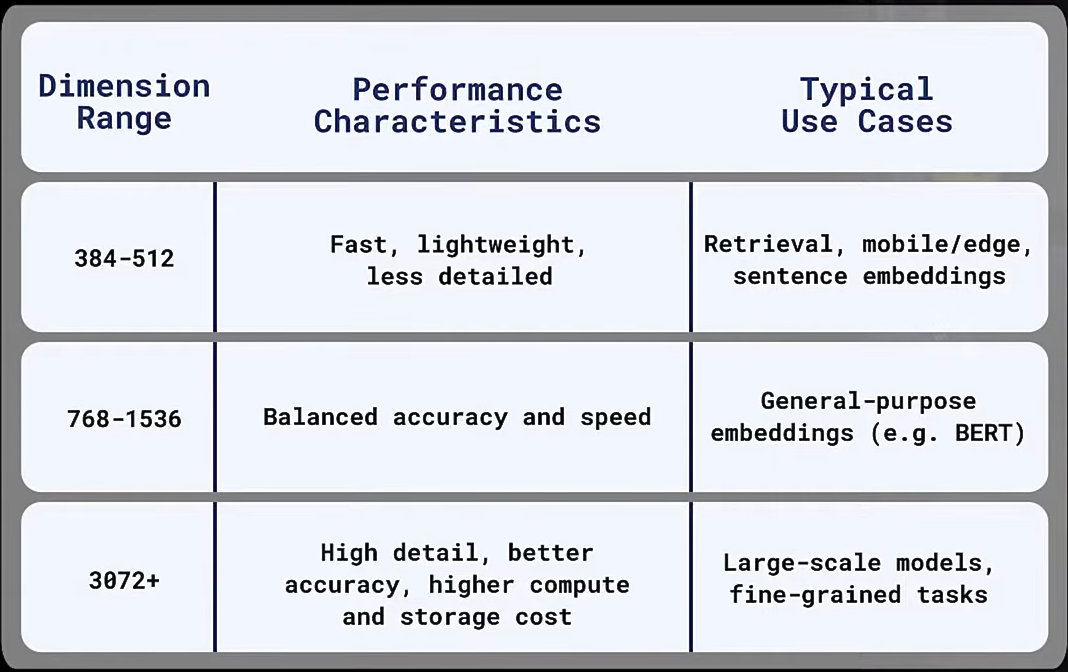

1536-dimensional vector (Float32) -> 6 KB
1M vectors -> 6 GB


1M 3072-dim vectors -> 12 GB

## Which embedding model should you choose?

* [Fastembed](https://github.com/qdrant/fastembed) - is a **lightweight (~67 MB)**, fast, Python library built for embedding generation! (384 embed dim by default)
* HuggingFace models
* Cloud base models:
    * *OpenAI* embed models
    * `jina-embeddings-v3`

## Payloads
**Metadata - Structured Information**
> First, need to create an index!!

* `Textual data` - descriptions, tags, categories
* `Numerical values` - dates or prices
* Invaluable for appying filters or sorting

**Не забыть!!** Чтобы выполнить `Filter Search` нужно перед поиском задать индекс для нужного поля!

**Типы индексов для разных данных**
* **KEYWORD** - для строковых полей (категории, теги)
* **INTEGER** - для целых чисел
* **FLOAT** - для чисел с плавающей точкой
* **BOOL** - для булевых значений
* **GEO** - для географических координат
* **TIMESTAMPS** - дата и время
* **ARRAYS** - массивы 

## Finding (filters, range etc) 

1. **MATCH** | Find products `where category = 'electronics'` == `"match": { "value": "electronics" }`
2. **MATCH Any (OR)** | Find items `where color = "red" OR "blue"` == `"match": { "any": ["red", "blue"] }`
3. **MATCH Except (NOT IN)** | Find items `that are not category = "banned"` == `"match": { "except": ["banned"] }`
4. **RANGE** | Find products `with price > 50 and price < 200` == `"range": { "gte": 50, "lte": 200 }`
5. **Logical filters** | Logical Operators (AND, OR, NOT), when use that use the query format: `must, should, must_not`

## Distance metrics
* **Cosine Similarity** $$cos(\theta) = (A \cdot B) / ( ||A|| * ||B|| ), where ||A|| = \sqrt{(a_1^2 + a_2^2+...+a_n^2)}$$
* **Euclidean Distance** matter when every dimension matter equally. It's scale sensitive (need scaling or normalizing). **Avoid it if you're comparing semantic vectors**, good for absolute values $$d(A, B) = \sqrt {\sum(A - B)^2}$$
* **Dot product** $$ \sum{(A * B)} $$

# Chunking Data for Better vector search results

## Chunking types

* **Fixed-size chunking**
    * Fixed number of tokens - eg. 200
    * Small overlap to preserve context
    * This could be the first chunking. The 2nd chunk might split in the middle of a sentence which is not great. And this is the operlapping text
* **Sentence-based chunking**
    * Sentences broken up by tokenizer
    * Groupped into chunks under specified wor count
* **Paragraph-based chunking** | maybe need fallback splitting
    * Uses a structure that usually already exists
    * Chunks the are semantically rich by default
* **Sliding Window Chunking** | uses if u want not missing anything rather than optimizing speed of storage, has high recall
    * Fixes problem of context loss at the boundaries
    * Define a window size and a stride
* **Recursive Chunking**
    * Uses a fallback hierarchy of separators
    * Preserves as much semantic coherence as possible
* **Semantic-Aware Chunking**
    * Uses embeddings to find meaning shifts
    * Slower and heavier, but the result is powerful

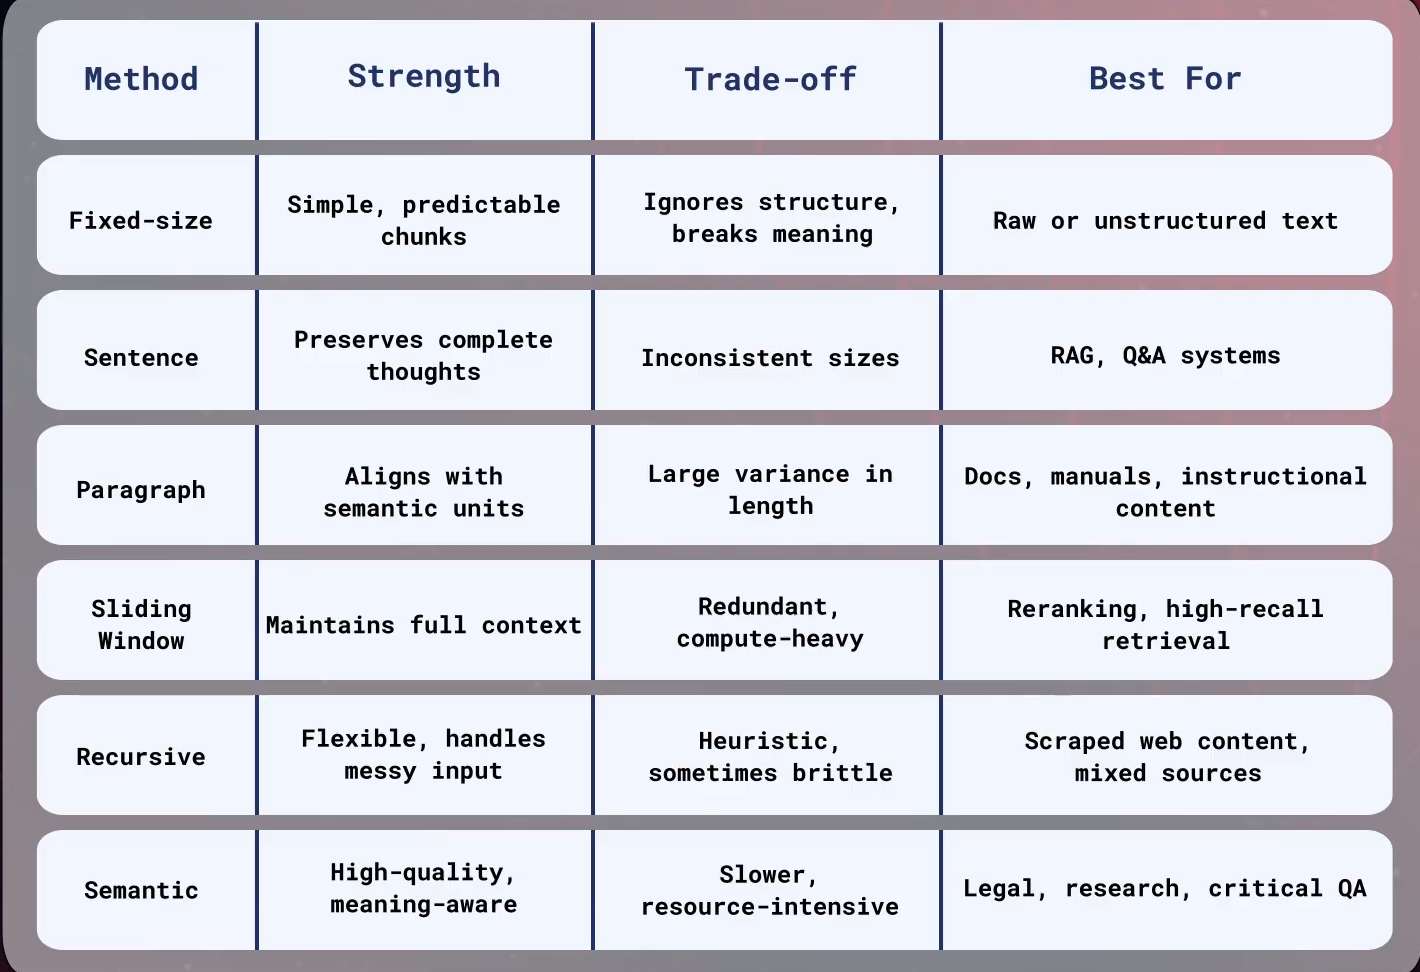

# Fast vector search | HNSW - Hierarchical Navigable Small World
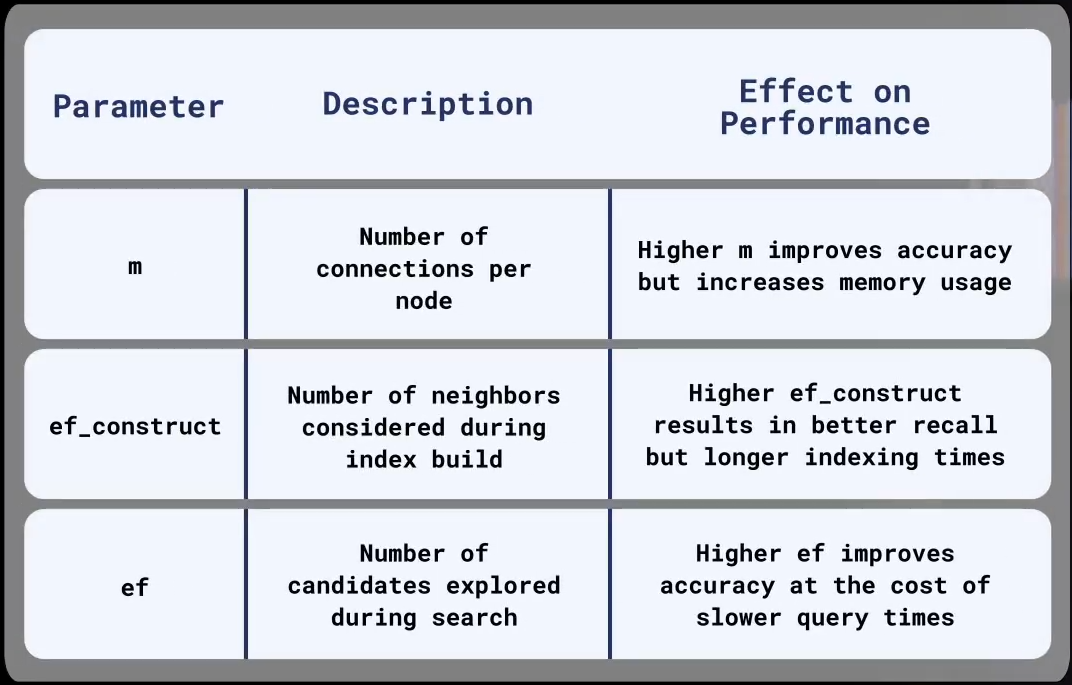

# Что такое HNSW?

**HNSW** (Hierarchical Navigable Small World) — это алгоритм для быстрого поиска похожих векторов.

**Аналогия из жизни (аэропорт):**
*   **Обычный поиск** (Flat index): Ты проходишь через ВСЕ дома в городе, чтобы найти нужный. Точность 100%, но очень медленно (миллиарды сравнений).
*   **HNSW:** У тебя есть карта с многоуровневыми магистралями (как слои в торте):
    *   **Самый верхний слой (мало точек):** Только самые крупные города/узлы. Ты быстро находишь примерный район.
    *   **Средний слой:** Дороги помельче. Ты уточняешь маршрут.
    *   **Нижний слой (все точки):** Ты находишь точный дом.

**Эффект:** HNSW находит 99% похожих векторов в **тысячи раз быстрее**, чем перебор всех подряд. Но он немного жертвует точностью (иногда пропускает идеальный вариант, но находит очень хороший).

---

## 2. Разбор параметров

Таблица описывает **три ключевых рычага**, которые ты можешь крутить в Qdrant. У каждого есть Trade-off (компромисс): или скорость/память, или точность.

### Параметр `m` (Number of connections per node)

**Что это?** У каждого вектора (точки) в графе есть максимум «дорог» (связей) к соседним точкам. Чем больше связей — тем лучше карта дорог.

**Как читать таблицу:**
*   `Higher m` (например, 32 или 64) → Точность выше (больше связей = меньше шансов потерять правильный путь), но память (RAM) быстро заканчивается, потому что хранить все связи — это долго.
*   `Lower m` (например, 4 или 8) → Экономия памяти, но можешь потерять точность.

**Совет для Qdrant:** Для 96% задач ставь `m = 16`. Это золотая середина.

---

### Параметр `ef_construct` (во время построения индекса)

**Что это?** Представь, что мы строим карту города. Алгоритм смотрит на кучу кандидатов (`ef_construct = 100`) и решает, с кем из них лучше построить дорогу.

**Как читать таблицу:**
*   `Higher ef_construct` → **Лучшее качество (recall)**. Карта продумана до мелочей. Но строить индекс (`indexing time`) придётся **очень долго** (Qdrant будет грузиться минуты или часы).
*   `Lower ef_construct` → Индекс строится быстро, но он «ленивый» и менее точный.

**Важно:** `ef_construct` никак не влияет на скорость поиска и память. Только на время запуска и на максимально возможную точность.

---

### Параметр `ef` (во время поиска, самое важное!)

**Что это?** Это твой «бинокль» во время поиска. Когда ты ищешь похожий вектор, алгоритм сначала смотрит на `ef` ближайших кандидатов, прежде чем выдать тебе топ-10 результатов.

**Как читать таблицу:**
*   `Higher ef` (например, 400) → Ты смотришь очень широко, почти как перебор. Точность отличная, но **время запроса (latency)** сильно растёт.
*   `Lower ef` (например, 40) → Ты быстро хватаешь первых попавшихся соседей. Очень быстрый ответ, но точность может упасть.

**Главное правило в Qdrant:**
> Значение `ef` должно быть **больше или равно** количеству результатов, которые ты хочешь получить (`limit`).
> *   Хочешь 10 результатов? Поставь `ef = 100` для хорошей точности.
> *   Нужна максимальная скорость? `ef = 20-40`.

---

## 3. Итоговая таблица решений (Шпаргалка)

| Что важно? | `m` | `ef_construct` | `ef` |
| :--- | :--- | :--- | :--- |
| **Максимальная точность** | Увеличивай (32-64) | Увеличивай (200-500) | Увеличивай (200-400) |
| **Минимум памяти** | Уменьшай (4-8) | Не важно | Не важно |
| **Быстрое построение индекса** (разовая операция) | Уменьшай (8) | Уменьшай (32-64) | — |
| **Быстрые ответы на запросы** (каждую секунду) | Не трогай (16) | Не трогай (100-200) | Уменьшай (40-64) |

### Как это настроить в Qdrant (код):

```python
from qdrant_client import QdrantClient
from qdrant_client.http.models import VectorParams, HnswConfigDiff

client = QdrantClient(":memory:") # или твой URL

client.create_collection(
    collection_name="my_vectors",
    vectors_config=VectorParams(size=768, distance="Cosine"),
    hnsw_config=HnswConfigDiff(
        m=16,                # связи (память)
        ef_construct=100,    # качество при построении
        ef=64                # компромисс скорости/точности при поиске
    )
)

# При поиске можно переопределить ef для конкретного запроса:
client.search(
    collection_name="my_vectors",
    query_vector=[0.1]*768,
    limit=10,
    hnsw_ef=128  # Временно повысить точность, ценой скорости
)
```

**Золотое правило новичка:** Начни со значений `m=16, ef_construct=100, ef=64`. Если ответы кажутся неточными — **первым делом увеличивай `ef`** (например, до 200). Если всё устраивает, но медленно — уменьшай `ef` до 40.

# Combine Search & Filtering with Qdrant Filterable HNSW


# Sparse Vector Explanation and Usage

**`Dense (полный) vector`, size 1000:** [0, 0, 0, 5.2, 0, 0, 0, 0, 3.1, 0, ..., 0, 0, 7.8]

**`Sparse (разряженный) vector`, size 1000:** [(3, 5.2), (8, 3.1), (999, 7.8)]

**`Inverted Index`** - inverted index maps each object to all sparse representation where this impact of this object is not known!

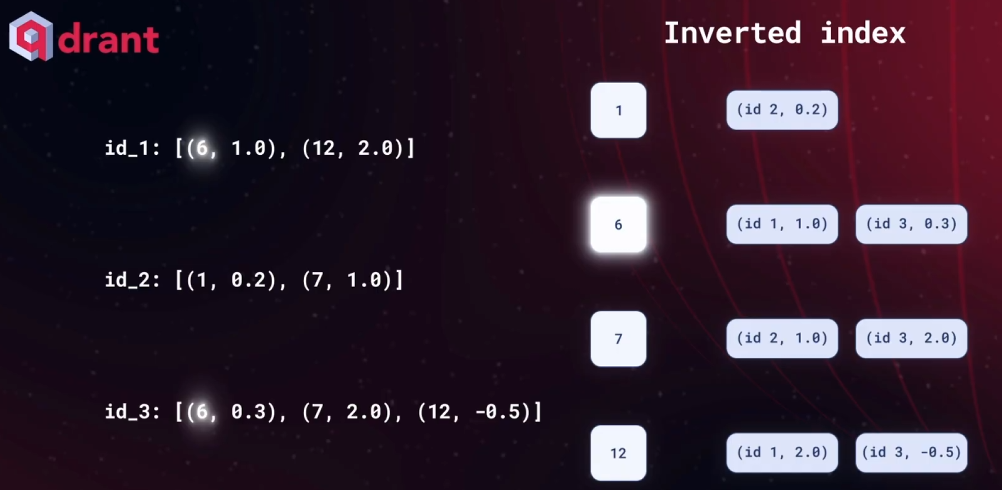

**Что такое инвертированный индекс? (Объяснение "на пальцах")**

`Прямой индекс` — "для каждого документа знаем его слова". 

`Инвертированный` — "для каждого слова знаем документы".

---

Аналогия с книгой рецептов:

Прямой индекс (sparse vector):
```text
Рецепт 1: [яйца, мука, сахар, молоко]
Рецепт 2: [яйца, мука, соль, масло]
Рецепт 3: [сахар, яйца, ванилин]
```

Инвертированный индекс (для быстрого поиска):
```text
яйца → {рецепт 1: 4.5, рецепт 2: 4.5, рецепт 3: 2.0}  # вес (важность) яиц в каждом рецепте
мука → {рецепт 1: 3.0, рецепт 2: 3.0}
сахар → {рецепт 1: 2.0, рецепт 3: 3.0}
соль → {рецепт 2: 1.5}
масло → {рецепт 2: 4.0}
ванилин → {рецепт 3: 1.0}
```
---

Зачем это нужно? Если я ищу рецепты с яйцами и мукой, я не буду сканировать 3 рецепта. Я:
* Возьму список рецептов для "яйца"
* Возьму список для "мука"
* Сделаю *union* (рецепты 1 и 2)
* Посчитаю суммарную важность

In [1]:
from dotenv import load_dotenv
import os
from qdrant_client import QdrantClient

load_dotenv()
endpoint = 'https://3a3321d0-e87a-4974-96a7-2ee60f22a3d4.eu-west-2-0.aws.cloud.qdrant.io'   # Cluster endpoint

client = QdrantClient(location=endpoint, api_key=os.getenv('Q_TOKEN'))
client

In [2]:
from qdrant_client import models

## Create a Collection with Sparse Vectors


Sparse vectors in Qdrant collections are configured using `sparse_vectors_config`.

Unlike in dense vector configuration `vectors_config`, we don’t need to define **size** or **distance metric** for sparse vectors:

- **Size** varies based on the number of non-zero elements in the sparse vector.

  > The maximum number of non-zero elements (i.e., the sparse vector’s size) is limited by the `uint32` type, meaning 4,294,967,296 non-zero elements.

- **Distance metric** for comparing sparse vectors is always the `Dot product`.

Sparse vectors are not the default in Qdrant (unlike dense vectors). That’s why, to configure collection with sparse vectors, we need to **give them a name.**

  > **Named vectors** additionally allow us to use multiple vectors for the same point, for example, one dense and one sparse.

In [4]:
c_name = "sparse_vector_lesson"

client.create_collection(
    collection_name=c_name,
    sparse_vectors_config={
        "sparse_vector": models.SparseVectorParams(),
    }
)

True

You can **optionally** configure the parameters of the `inverted_index`, for example:

- `full_scan_threshold` (integer) – up to this number of vectors (not including this number), the inverted index won’t be used to compare sparse vectors (though **it will still be built**). Instead, vectors will be compared directly.
- `on_disk` – whether the index is stored on disk or kept in RAM. The default is `False`, meaning it’s stored in RAM.
- `datatype` – precision of the values (non-zero weights) stored in the index. Options are `uint8`, `float16`, or `float32`. Default is `float32`.

    > No matter which `datatype` you choose, the original values **will still be stored on disk**.

> Only configure these parameters if you’re confident about their impact, the default values are chosen to work well for most use cases.

In [5]:
client.get_collection(collection_name=c_name)

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=0, points_count=0, segments_count=2, config=CollectionConfig(params=CollectionParams(vectors={}, shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=True, sparse_vectors={'sparse_vector': SparseVectorParams(index=None, modifier=None)}), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None, prevent_unoptimized=None), wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0, wal_retain_closed=1), quantizati

In [ ]:
if client.collection_exists(c_name):
    client.delete_collection(c_name)
    
client.create_collection(
    collection_name=c_name,
    sparse_vectors_config={
        "sparse_vector": models.SparseVectorParams(
            index=models.SparseIndexParams(  # inverted index params
            full_scan_threshold=0, # full scan search, not using inverted index
            on_disk=False, # where inverted index is stored
            datatype=models.VectorStorageDatatype("float32")  # precision of values stored in inverted index
            )
        )
    }
)

True

> The inverted index is **always built** for sparse vectors

## Insert Sparse vectors into the Collection

Let's insert points with sparse vectors into our "sparse_vectors_collection".

Sparse vectors in Qdrant are represented by:

- **indices** – the indices of non-zero dimensions (stored as `uint32`, so they can range from 0 to 4,294,967,295).
- **values** – the values of these non-zero dimensions (stored as a `float`).

There are two important rules when creating a sparse vector in Qdrant:

- The indices in a sparse vector must be **unique**.
- The indices array must be the **same length** as the values array.

Don't confuse **indices** with the sparse vector's **inverted index**. `indices` represent the non-zero dimensions of a sparse vector, while the `inverted index` is a data structure that helps compare sparse vectors efficiently.

In [8]:
client.upsert(
    collection_name=c_name,
    points=[
        models.PointStruct(
            id=1,
            payload={},
            vector={ # vector named "sparse_vector"
                "sparse_vector": models.SparseVector(
                    indices=[1, 2, 3],  # uint32
                    values=[0.2, -0.2, 0.1]  # float
                )
            }
        ),
        models.PointStruct(
            id=2,
            payload={},
            vector={  # vector named "sparse_vector"
                "sparse_vector": models.SparseVector(
                    indices=[1, 5],
                    values=[0.1, 0.1]
                )
            }
        )
    ]
)

UpdateResult(operation_id=1, status=<UpdateStatus.COMPLETED: 'completed'>)

## Running Similarity Search on Sparse Vectors

In [9]:
client.query_points(
    collection_name=c_name,
    using='sparse_vector',
    query=models.SparseVector(
        indices=[1, 3],
        values=[1, 1]
    ),
    with_payload=True  # to see the top 1 similar vector
)

QueryResponse(points=[ScoredPoint(id=1, version=1, score=0.3, payload={}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=2, version=1, score=0.1, payload={}, vector=None, shard_key=None, order_value=None)])

Let's understand why we got Point 1 as the answer.

In the collection, we have two points:

- **Point 1** has three non-zero values:  
  `values = [0.2, -0.2, 0.1]` with `indices = [1, 2, 3]`

- **Point 2** has two non-zero values:  
  `values = [0.1, 0.1]` with `indices = [1, 5]`

Our query has `indices = [1, 3]` with corresponding `values = [1, 1]`.

The similarity score for sparse vectors is calculated by comparing **only the matching indices** shared between the query and the points:  
`[1, 3]` for Point 1, and `[1]` for Point 2.

We multiply the corresponding values and sum them up:

- `score(query, Point 1) = 1 * 0.2 + 1 * 0.1 = 0.2`
- `score(query, Point 2) = 1 * 0.1 = 0.1`

Since `0.2` is higher than `0.1`, **Point 1 is more similar** to our query.

> Search on sparse vectors is always exact.

# Increase Search Relevance with Sparse vectors

## 1. Connect to qdrant

In [1]:
from dotenv import load_dotenv
from qdrant_client import QdrantClient, models
import os

endpoint = 'https://3a3321d0-e87a-4974-96a7-2ee60f22a3d4.eu-west-2-0.aws.cloud.qdrant.io'   # Cluster endpoint

load_dotenv()
client = QdrantClient(location=endpoint, api_key=os.getenv('Q_TOKEN'))
client

In [2]:
client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='bm25_vector_collection'), CollectionDescription(name='movies'), CollectionDescription(name='sparse_vector_lesson'), CollectionDescription(name='splade_vector_collection')])

`TF (Term Frequency)` - how often the word meet in the document.<br>
`IDF (Inverse Document Frequency)` - A numerical way to describe rarity of word or to describe this importance. Rarity of keyword in the corpus (up) <-> IDF (keyword) (up)

[(101, 1.0 * IDF("cheese")), (151, 1.0 * IDF("grated")), ...]

TF-IDF has 2 main problems:
* No saturation
* Don't consider the document length 

`BM25 (Best Matching 25)`

**Lexical Retrieval with BM25 in Qdrant**

The BM25 formula can be represented as follows:

$$\text{BM25}(Q, D) = \sum_{i=1}^n \text{IDF}(q_i) \cdot \text{function} \left( \text{TF}(q_i, D), k_1, b, |D|, \text{avg}_{\text{corpus}} |D| \right)\$$

Qdrant provides tooling to compute IDF on the server side. To enable this, we need to activate the `IDF modifier` when configuring sparse vectors in a collection.

>   Once enabled, **IDF is maintained at the collection level**.

When using any retrieval formula that includes IDF, such as BM25, we no longer need to include the IDF component in the sparse document representations. This leaves us with the following values of the documents' words:

$$\text{BM25}(d_i) = \text{function} \left( \text{TF}(d_i, D), k_1, b, |D|, \text{avg}_{\text{corpus}} |D| \right)$$

The IDF component will be applied by Qdrant automatically when computing similarity scores.

## 2. Create a Collection for BM25-based Retrieval

In [5]:
cn_bm25 = "bm25_vector_collection"
cn_bm25

'bm25_vector_collection'

In [7]:
client.create_collection(
    collection_name=cn_bm25,
    sparse_vectors_config={
        "bm25_sparse_vector": models.SparseVectorParams(
            modifier=models.Modifier.IDF  # Inverce Document Frequency
        )
    }
)

True

## 3. Create BM25-based Sparse Vectors with FastEmbed & Insert Them into the Collection

The FastEmbed Qdrant library provides a way to generate BM25 formula-based sparse representations tailored for Qdrant specifics.  
The integration between Qdrant and FastEmbed allows you to simply pass your texts and BM25 formula parameters when indexing documents to Qdrant. The conversion to sparse vectors happens under the hood.

**Note:** Don't forget to enable the IDF modifier when using BM25-based sparse representations generated by FastEmbed, as they intentionally exclude this component.

**BM25 in FastEmbed: Implementation Details**<br>
Corpus Average Length

Qdrant and FastEmbed do not compute `avg_corpus |D|` (the average document length in the corpus). You must **estimate** and **provide** this value as a BM25 parameter.

**Default BM25 Parameters in FastEmbed**
- `k = 1.2 `
- `b = 0.75`  

**Text Processing Pipeline**

FastEmbed uses the Snowball stemmer to reduce words to their root or base form, and applies language-specific stop word lists (e.g., and, or in English) to reduce vocabulary size and improve retrieval quality.

Therefore, **FastEmbed's BM25 works out of the box for the following languages**:  
Arabic, Danish, Dutch, English, Finnish, French, German, Greek, Hungarian, Italian, Norwegian, Portuguese, Romanian, Russian, Spanish, Swedish, Tamil, and Turkish.

In [3]:
grocery_items_descriptions = [
    "Grated hard cheese",
    "White crusty bread roll",
    "Mac and cheese"
]

# Estimating the average length of documents in the corpus
avg_doc_len = sum(
    len(description.split()) for description in grocery_items_descriptions
) / len(grocery_items_descriptions)
print(f"Average doc len: {avg_doc_len}")

Average doc len: 3.3333333333333335


In [7]:
grocery_items_descriptions

{'Grated hard cheese', 'Mac and cheese', 'White crusty bread roll'}

In [ ]:
client.upsert(
    collection_name=cn_bm25,
    points=[
        models.PointStruct(
            id=i,
            payload={"text": description},
            vector={
                "bm25_sparse_vector": models.Document(  # to run FastEmbed unrder the hood
                    text=description,
                    model="Qdrant/bm25",
                    options={"avg_len": avg_doc_len}  # {"avg_len": avg_doc_len, "k": 1.2, "b": 0.85} To pass BM25 params, here we're using default k & b for the BM25 formula
                )
            }
        )
    for i, description in enumerate(grocery_items_descriptions, 1)]
)

UpdateResult(operation_id=1, status=<UpdateStatus.COMPLETED: 'completed'>)

## 4: Lexical Retrieval with BM25 & Qdrant

Now let's test our BM25-based lexical search in Qdrant.

Suppose we're searching for the word "cheese" — this is our query. Let's break down what happens with this query and the documents indexed to Qdrant in the previous step.

---

**4.1**

For every keyword in the query that is not a stop word in the target language (in our case, English, and "cheese" is not a stop word):

- FastEmbed extracts the **stem** (root/base form) of the word.
  - "cheese" becomes "chees"
- The stem is then mapped to a corresponding **index** from the vocabulary.
  - "chees" -> 1496964506

---

**4.2**

Qdrant lookups up this keyword **index** (1496964506) in the **inverted index**, introduced in the previous video.

For every document (found via the inverted index) that contains the keyword "cheese", we have the BM25-based score for "cheese" in that particular document, precomputed by FastEmbed and stored in **Step 3**:

`functionFastEmbed (TF("cheese", D), k1, b, |D|, avgCorpus |D|)`

---

**4.3**

Qdrant scales this document-specific score by the **IDF** of the keyword "cheese", calculated across the entire corpus:

$$IDF("cheese") · functionFastEmbed (TF("cheese", D), k1, b, |D|, avgCorpus |D|)$$

---

**4.4**

The final similarity score between the query and a document is the **sum of the scores of all matching keywords**:

$$BM25("cheese", D) = Σ_{i=1}^{1} IDF("cheese") · function (TF("cheese", D), k1, b, |D|, avgCorpus |D|)$$

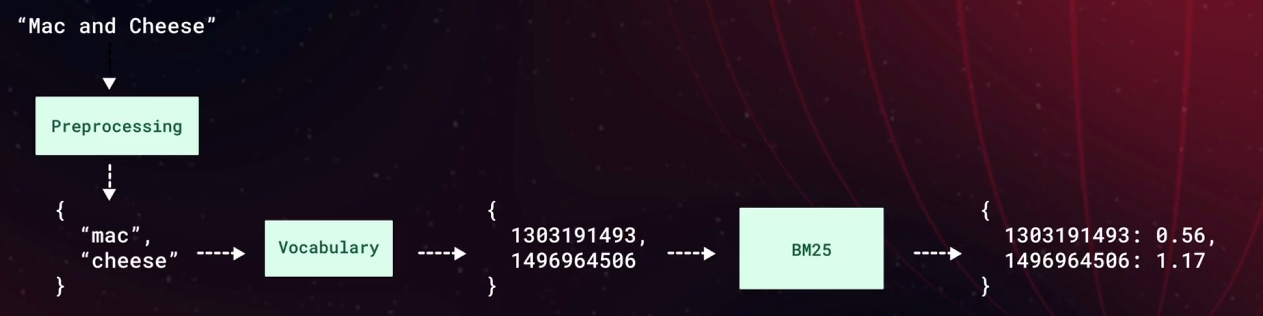

In [6]:
client.query_points(
    collection_name=cn_bm25,
    using="bm25_sparse_vector",
    limit=3,
    query=models.Document(  # to run FastEmbed under the hood
        text="cheese",
        model="Qdrant/bm25"
    ),
    with_payload=True
)

QueryResponse(points=[ScoredPoint(id=3, version=1, score=0.5619608, payload={'text': 'Mac and cheese'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=1, version=1, score=0.49005118, payload={'text': 'Grated hard cheese'}, vector=None, shard_key=None, order_value=None)])

BM25 retrieved only the documents that contain the keyword "cheese", as BM25-based retrieval works strictly with **exact keyword matches**.

The description "Mac and cheese" was ranked higher because the BM25-estimated value of "cheese" is greater in this text than in "Grated hard cheese".

It's higher because "and" is a stop word and is excluded from the calculation.

So in "Mac and cheese", "cheese" is one of two considered words, whereas in "Grated hard cheese", it's one of three – giving it lower relative importance.

## 5.Sparse Neural Retrieval with SPLADE++ in Qdrant

**SPLADE** - Sparse Lexical and Expansion model

In [7]:
cn_splade_vs = "splade_vector_collection"
cn_splade_vs

'splade_vector_collection'

> Note that we’re **not configuring the Inverse Document Frequency (IDF) modifier** here, unlike in BM25-based retrieval. <br>
> SPLADE models don’t rely on corpus-level statistics like IDF to estimate word relevance. Instead, they generate term weights in sparse representations based on their interactions within the encoded text.

In [10]:
client.create_collection(
    collection_name=cn_splade_vs,
    sparse_vectors_config={
        "splade_sparse_vector": models.SparseVectorParams()
    }
)

True

## 6. Create SPLADE++ SPARSE VECTORS with FastEmbed & Insert them into the collection

The FastEmbed library provides **SPLADE++**, one of the latest models in the SPLADE family.

As a result, this step looks mostly identical to **Step 3** of this tutorial. However, under the hood, the process of converting a document to a sparse representation is quite different.

> **Documents to SPLADE++ Sparse Representations**

SPLADE models generate sparse text representations made up of **tokens** produced by the SPLADE tokenizer.

- Tokenizers break text into smaller units called **tokens**, which form the model's **vocabulary**. Depending on the tokenizer, these tokens can be words, subwords, or even characters.

- SPLADE models operate on a fixed **vocabulary of 30,522 tokens**.

> **Text to Tokens**

Each document is first tokenized and the resulting tokens are mapped to their corresponding indices in the model's vocabulary. These indices are then used in the final sparse representation.

- You can explore this process in the **Tokenizer Playground** by selecting the **custom** tokenizer and entering `Qdrant/Splade_PP_en_v1`.
- For example, `"cheese"` is mapped to token index **8808**, and `"mac"` to **6097**.

> **Weighting Tokens**

The tokenized text, now represented as token indices, is passed through the SPLADE model.

SPLADE **expands** the input by adding contextually relevant tokens and simultaneously assigns each token in the final sparse representation a **weight** that reflects its role in the text.

> **SPLADE++ Document Expansion**

For example, `"mac and cheese"` will be expanded to:  
`"mac and cheese dairy apple dish & variety brand food made, foods difference eat restaurant of"`, resulting in a SPLADE-generated sparse representation with **17 non-zero values**.

If you'd like to experiment with SPLADE's expansion behavior, check out our documentation on **using SPLADE in FastEmbed**. It includes a utility function to decode SPLADE++ sparse representations back into tokens with their corresponding weights.

In [10]:
client.upsert(
    collection_name=cn_splade_vs,
    points=[
        models.PointStruct(
            id=i,
            payload={"text": desc},
            vector={
                "splade_sparse_vector": models.Document(
                text=desc,
                model="prithivida/Splade_PP_en_v1"
                )
            }
        )
        for i, desc in enumerate(grocery_items_descriptions)    
    ]
)

UpdateResult(operation_id=2, status=<UpdateStatus.COMPLETED: 'completed'>)

## 7. Sparse Neural Retrieval with SPLADE++ & Qdrant

Conversion of a query to a sparse representation by SPLADE++ works exactly the same way as for documents.

Let's see what sparse neural retrieval brings to the table compared to BM25-based lexical retrieval.

We'll test a query where the meaning of the keyword depends heavily on context: **"a not soft cheese"**. In our toy dataset of grocery item descriptions, the most fitting result should be **"grated hard cheese"**.

In [11]:
client.query_points(
    collection_name=cn_splade_vs,
    using="splade_sparse_vector",
    limit=3,
    query=models.Document(
        text="A not soft cheese",
        model="prithivida/Splade_PP_en_v1"
    ),
    with_payload=True
)

QueryResponse(points=[ScoredPoint(id=0, version=2, score=27.169666, payload={'text': 'Grated hard cheese'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=2, version=2, score=10.543147, payload={'text': 'Mac and cheese'}, vector=None, shard_key=None, order_value=None), ScoredPoint(id=1, version=2, score=1.8311474, payload={'text': 'White crusty bread roll'}, vector=None, shard_key=None, order_value=None)])

Yet for BM25, **"mac and cheese"** would be ranked higher, since "cheese", the only matching keyword between the query and the documents, plays a more prominent role in that description compared to "grated hard cheese".

Maybe better than splade

https://qdrant.tech/articles/minicoil/

# Hybrid Search Explanation and Overview

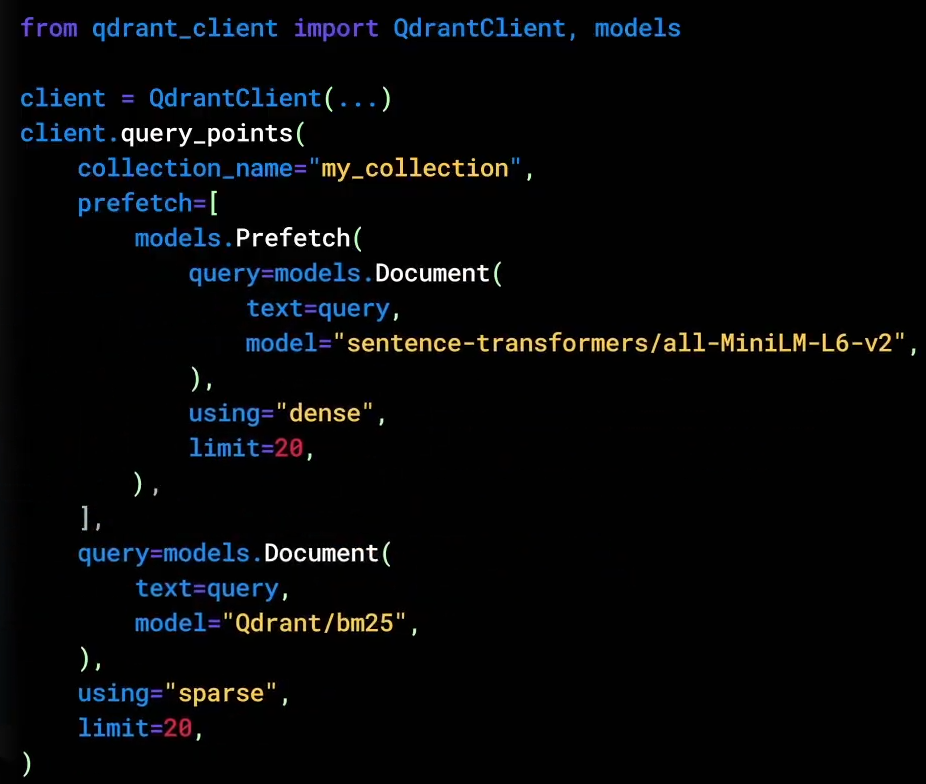

Fusion algorithms created to solve problem with mixed search!

Reciprocal Rank Fusion (RRF)

$$RRF(d)=\sum_{r\in R}\frac{1}{k+r(d)}$$

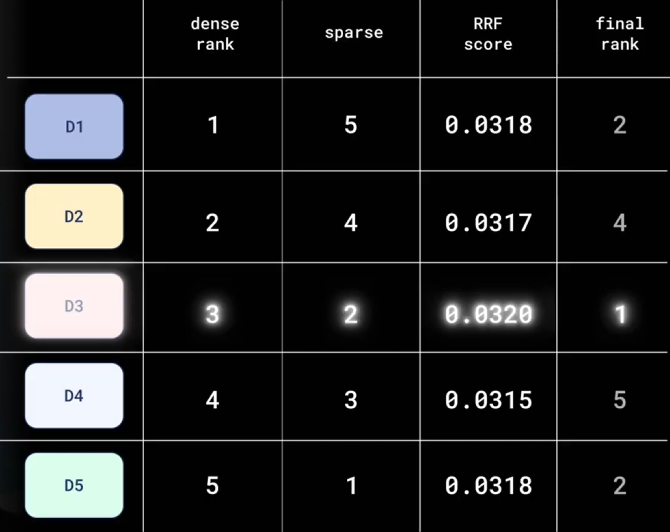

Code:

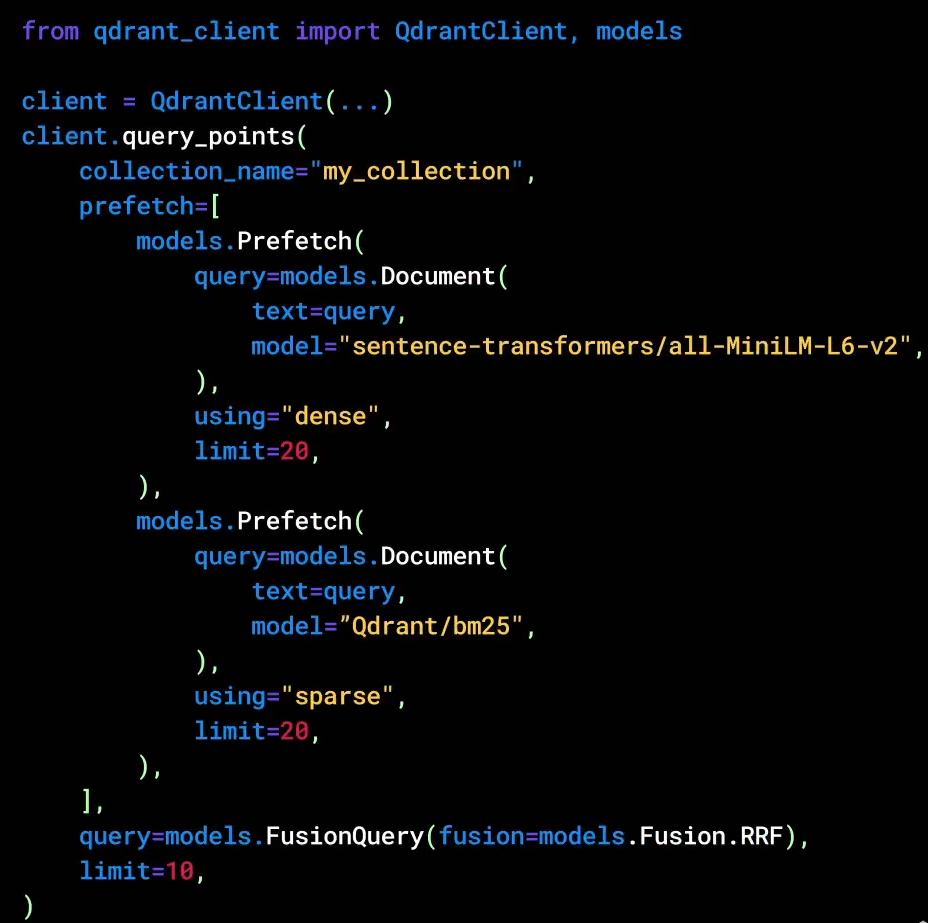

In [12]:
client

## Creating the collection

In [13]:
cn_hs = "hybrid_search_demo"
cn_hs

'hybrid_search_demo'

In [14]:
client.create_collection(
    collection_name=cn_hs,
    vectors_config={
        "dense": models.VectorParams(
            distance=models.Distance.COSINE,
            size=384
        )
    },
    sparse_vectors_config={
        "sparse": models.SparseVectorParams(
            modifier=models.Modifier.IDF
        )
    }
)

True

In [22]:
documents = [
    "Aged Gouda develops a crystalline texture and nutty flavor profile after 18 months of maturation.",
    "Mature Gouda cheese becomes grainy and develops a rich, buttery taste with extended aging.",
    "Brie cheese features a soft, creamy interior surrounded by an edible white rind.",
    "This French cheese has a flowing, buttery center encased in a bloomy white crust.",
    "Fresh mozzarella pairs beautifully with ripe tomatoes and basil leaves.",
    "Classic Margherita pizza topped with tomato sauce, mozzarella, and fresh basil.",
    "Parmesan requires at least 12 months of cave aging to develop its signature sharp taste.",
    "Parmigiano-Reggiano's distinctive piquant flavor comes from extended maturation in controlled environments.",
    "Grilled cheese sandwiches are the ultimate American comfort food for cold winter days.",
    "Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich.",
]

In [28]:
type(client._embed_models)

method

In [31]:
import uuid

client.upsert(
    collection_name=cn_hs,
    points=[
        models.PointStruct(
            id=uuid.uuid4().hex,
            vector={
                "dense": models.Document(
                    text=doc,
                    model="sentence-transformers/all-MiniLM-L6-v2",
                ),
                "sparse": models.Document(
                    text=doc,
                    model="Qdrant/bm25",
                )
            },
            payload={"text": doc}
        )
        for i, doc in enumerate(documents)
    ]
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model.onnx:   0%|          | 0.00/90.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

UpdateResult(operation_id=1, status=<UpdateStatus.COMPLETED: 'completed'>)

## Validating the outputs of sparse and dense search
Both of models may return completely differen sets of results for the same query. Let's check if that's the case.

In [33]:
def dense_search(query: str) -> list[models.ScoredPoint]:
    response = client.query_points(
        collection_name=cn_hs,
        query=models.Document(
            text=query,
            model="sentence-transformers/all-MiniLM-L6-v2",
        ),
        using="dense",
        limit=3
    )
    return response.points

In [39]:
def sparse_search(query: str) -> list[models.ScoredPoint]:
    response = client.query_points(
        collection_name=cn_hs,
        query=models.Document(
            text=query,
            model="Qdrant/bm25"
        ),
        using="sparse",
        limit=3
    )
    
    return response.points

In [35]:
queries = [
    "nutty aged cheese",
    "soft French cheese",
    "pizza ingridients",
    "a good lunch"
]
queries

['nutty aged cheese',
 'soft French cheese',
 'pizza ingridients',
 'a good lunch']

In [40]:
for q in queries:
    print("Query:", q)
    
    dense_res = dense_search(q)
    print("Dense results:")
    for res in dense_res:
        print("\t-", res.payload["text"], res.score)
        
    sparse_res = sparse_search(q)
    print("Sparse results:")
    for res in sparse_res:
        print("\t-", res.payload["text"], res.score)
    print()

Query: nutty aged cheese
Dense results:
	- Mature Gouda cheese becomes grainy and develops a rich, buttery taste with extended aging. 0.5829767
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 0.47647107
	- This French cheese has a flowing, buttery center encased in a bloomy white crust. 0.45055333
Sparse results:
	- Aged Gouda develops a crystalline texture and nutty flavor profile after 18 months of maturation. 5.1563325
	- Mature Gouda cheese becomes grainy and develops a rich, buttery taste with extended aging. 3.0210652
	- Parmesan requires at least 12 months of cave aging to develop its signature sharp taste. 1.8819332

Query: soft French cheese
Dense results:
	- This French cheese has a flowing, buttery center encased in a bloomy white crust. 0.6242111
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 0.60305476
	- Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich. 0.468

## Hybrid Search

In [43]:
def rrf_search(query: str) -> list[models.ScoredPoint]:
    response = client.query_points(
        collection_name=cn_hs,
        prefetch=[
            models.Prefetch(
                # sparse search
                query=models.Document(
                    text=query,
                    model="Qdrant/bm25"
                ),
                using="sparse",
                limit=3
            ),
            models.Prefetch(
                query=models.Document(
                text=query,
                model="sentence-transformers/all-MiniLM-L6-v2",
                ),
                using="dense",
                limit=3
            ),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=3
    )
    
    return response.points

In [44]:
for q in queries:
    print("Query:", q)
    
    rrf_res = rrf_search(q)
    print("RRF results:")
    for res in rrf_res:
        print("\t-", res.payload["text"], res.score)

Query: nutty aged cheese
RRF results:
	- Mature Gouda cheese becomes grainy and develops a rich, buttery taste with extended aging. 0.8333334
	- Aged Gouda develops a crystalline texture and nutty flavor profile after 18 months of maturation. 0.5
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 0.33333334
Query: soft French cheese
RRF results:
	- This French cheese has a flowing, buttery center encased in a bloomy white crust. 1.0
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 0.6666667
	- Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich. 0.5
Query: pizza ingridients
RRF results:
	- Classic Margherita pizza topped with tomato sauce, mozzarella, and fresh basil. 1.0
	- Fresh mozzarella pairs beautifully with ripe tomatoes and basil leaves. 0.33333334
	- Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich. 0.25
Query: a good lunch
RRF re

## Distribution-Based Score Fusion

RRF is not the only supported fusion method. DBSF is another option that normalizes the scores of the points in each query, and sums the scores of the same point across different queries.<br> 
Choosing a different algorithm can definitely impact the final outputs, so let's see how they are going to look like.

In [45]:
def dbsf_search(query: str) -> list[models.ScoredPoint]:
    res = client.query_points(
        collection_name=cn_hs,
        prefetch=[
            models.Prefetch(
                query=models.Document(
                        text=query,
                        model="Qdrant/bm25",
                ),
                using="sparse",
                limit=3,
            ),
            models.Prefetch(
                query=models.Document(
                    text=query,
                    model="sentence-transformers/all-MiniLM-L6-v2",
                ),
                using="dense",
                limit=3
            )
        ],
        query=models.FusionQuery(fusion=models.Fusion.DBSF),
        limit=3
    )
    
    return res.points

In [46]:
for q in queries:
    print("Query:", q)
    
    dbsf_res = dbsf_search(q)
    print("RRF results:")
    for res in dbsf_res:
        print("\t-", res.payload["text"], res.score)

Query: nutty aged cheese
RRF results:
	- Mature Gouda cheese becomes grainy and develops a rich, buttery taste with extended aging. 1.1558483
	- Aged Gouda develops a crystalline texture and nutty flavor profile after 18 months of maturation. 0.6808001
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 0.43620512
Query: soft French cheese
RRF results:
	- This French cheese has a flowing, buttery center encased in a bloomy white crust. 1.2130749
	- Brie cheese features a soft, creamy interior surrounded by an edible white rind. 1.1703095
	- Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich. 0.6166155
Query: pizza ingridients
RRF results:
	- Classic Margherita pizza topped with tomato sauce, mozzarella, and fresh basil. 1.1872137
	- Fresh mozzarella pairs beautifully with ripe tomatoes and basil leaves. 0.44500765
	- Croque Monsieur combines ham and Gruyère in France's answer to the toasted cheese sandwich. 0.36777

# Reduce Storage & Maintain Accuracy with Qdrant Vector Quantinization

There are three main methods:
* Scalar Qantinization
* Binary Qantinization
* Product Qantinization

## Scalar Quantinization (most simple and effective)

> Это метод сжатия векторов, когда каждый float32 (4 байта) заменяется на int8 (1 байт) или uint8. Это уменьшает размер вектора в 4 раза, но с небольшой потерей точности.

In Qdrant each dim represented by float32 value

int8 = 1 byte -> from [-128 to 127], or [0, to 255]. This results in a 75% in memory.

**Как это работает?**
1. Берем диапазон значений исходного вектора (например, от -1.0 до +1.0)
2. Разбиваем его на 256 уровней (потому что int8 от -128 до +127 — это 256 значений)
3. Каждое float-значение заменяем ближайшим целым числом из этого диапазона

Формула: `quantized = round((value - min_range) / (max_range - min_range) * 255) - 128`

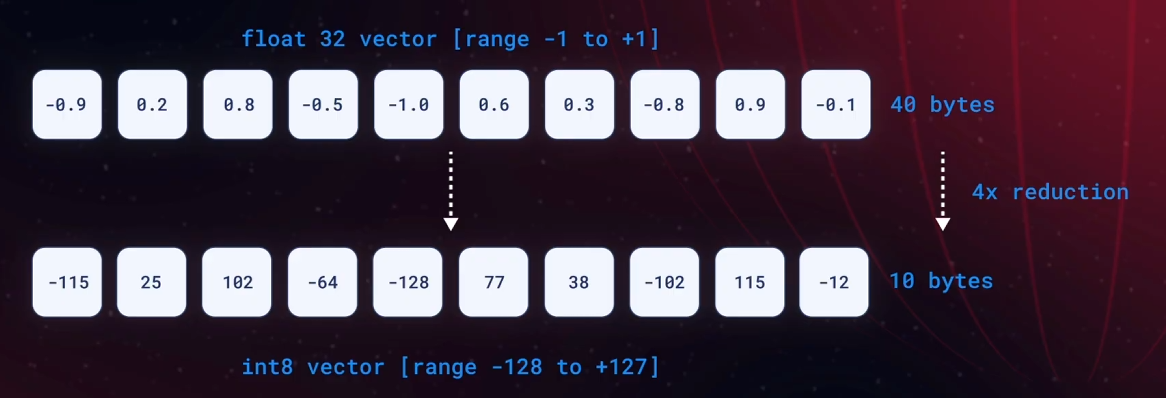

```python
from qdrant_client import QdrantClient, models
import os

client = QdrantClient(url=os.getenv("QDRANT_URL"), api_key=os.getenv("QDRANT_API_KEY"))

# For Colab:
# from google.colab import userdata
# client = QdrantClient(url=userdata.get("QDRANT_URL"), api_key=userdata.get("QDRANT_API_KEY"))

# Scalar quantization setup
client.create_collection(
    collection_name="scalar_collection",
    vectors_config=models.VectorParams(
        size=1536,
        distance=models.Distance.COSINE,
        on_disk=True,  # Move originals to disk
    ),
    quantization_config=models.ScalarQuantization(
        scalar=models.ScalarQuantizationConfig(
            type=models.ScalarType.INT8,
            quantile=0.99,  # Exclude extreme 1% of values
            always_ram=True,  # Keep quantized vectors in RAM
        )
    ),
)

```

## Binary Qantization (very strength quantization)

> Работает путем преобразования высокопространственных векторов в простые бинарные представления, то есть в 0 или 1. Значения больше чем 0 будут 1, а меньше 0. Ускоряет примерно в 40 раз

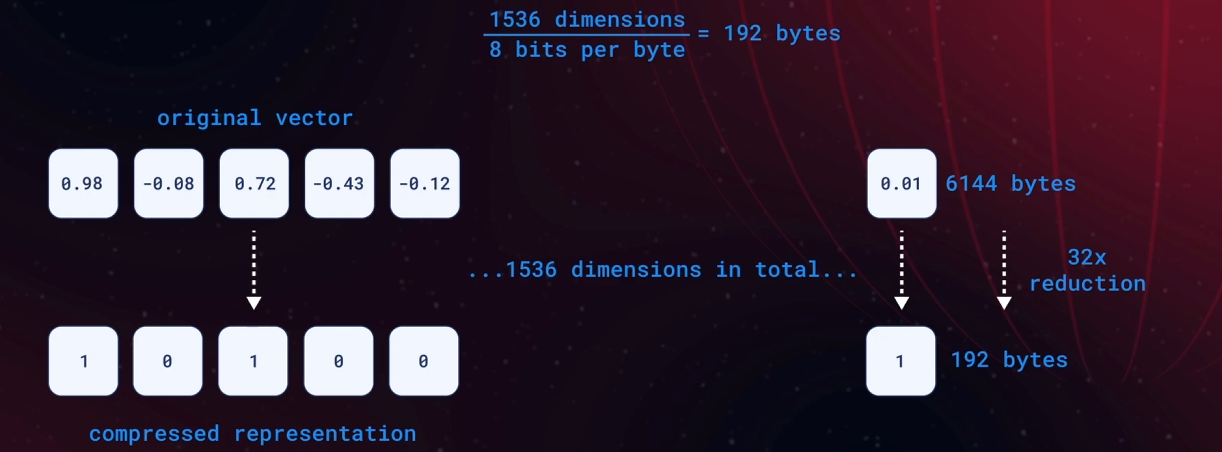

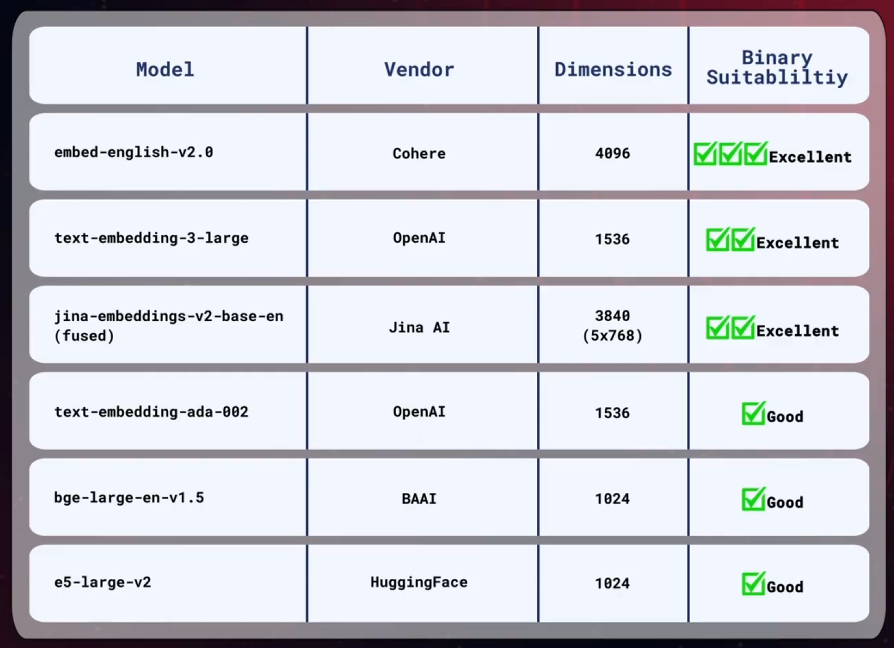

```python
# Binary quantization setup  
client.create_collection(
    collection_name="binary_collection",
    vectors_config=models.VectorParams(
        size=1536,
        distance=models.Distance.COSINE,
        on_disk=True,
    ),
    quantization_config=models.BinaryQuantization(
        binary=models.BinaryQuantizationConfig(
            encoding=models.BinaryQuantizationEncoding.ONE_BIT,
            always_ram=True,
        )
    ),
)
```

## Product Quantinization
Don't recommend cause high accuracy lost. Need thin configuration.
> It compress highdimensional vectors by representing them with a smaller set of 'representative points'.

**Steps:**
1. Split the original high dim. vector into smaller sub vectors. And each sub vector represents a segment of the original vector. This way we can capture different charasteristics of our data. 
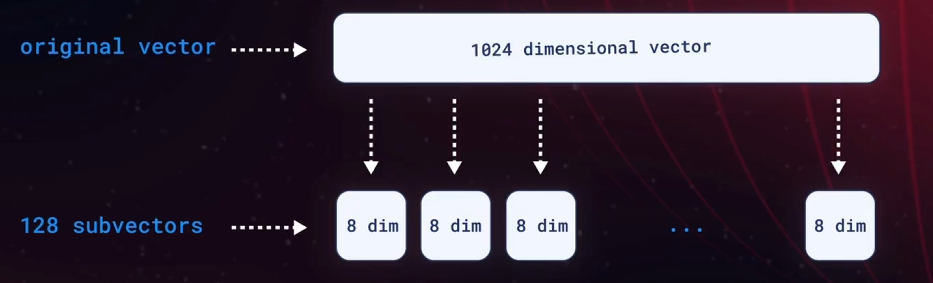
2. 
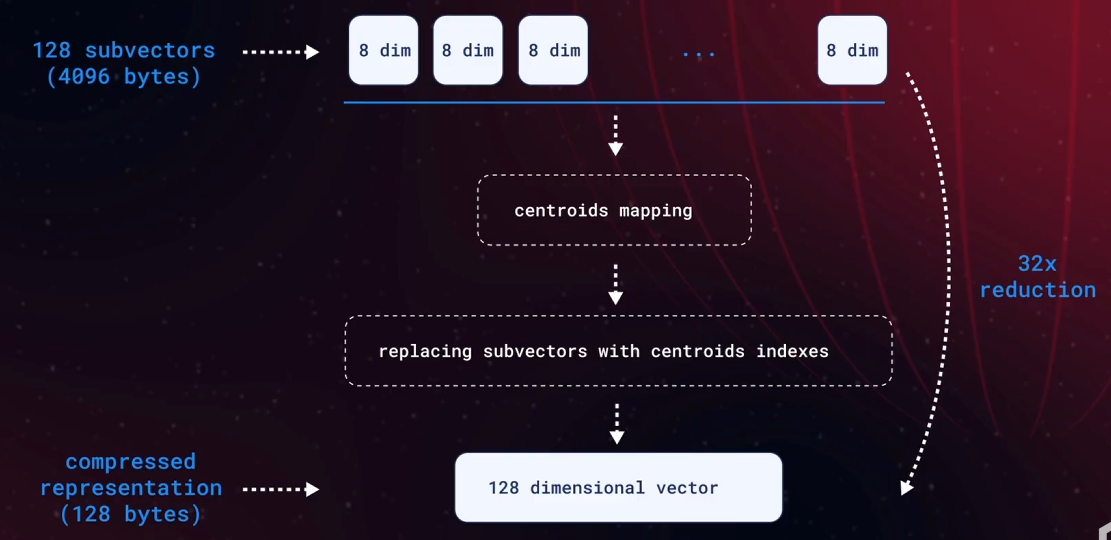

```python
# Product quantization setup
client.create_collection(
    collection_name="pq_collection",
    vectors_config=models.VectorParams(
        size=1024,
        distance=models.Distance.COSINE,
        on_disk=True,
    ),
    quantization_config=models.ProductQuantization(
        product=models.ProductQuantizationConfig(
            compression=models.CompressionRatio.X32, #or X4, X8, X16, X32 and X64
            always_ram=True,
        )
    ),
)
```

**Summarize**

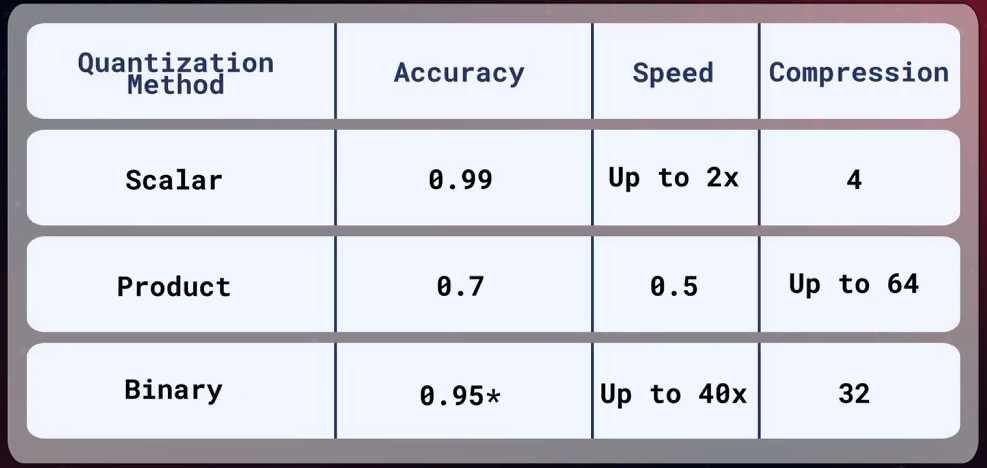

Также нужно учитывать, что `qdrant` **хранит оригинальные не квантинизированные вектора в коллекции**, поэтому можно безопасно переключаться между методами квантинизации и менять их!

Можно также переместить оригинальные вектора на диск, чтобы уменьшить потребление *RAM*. В этом случае будет выполняться быстрый поиск только по векторам в *RAM*.

**ВАЖНО!! Без указания параметра `on_disk: True` мы не увидим квантинизации! Поэтому всегда нужно указывать!**

> Когда что использовать? 🎯

**Scalar Quantization (SQ)**
* ✅ Точность критична (>99% recall)
* ✅ Векторы нормализованы в известный диапазон
* ✅ Нужно хранить до 1 млн векторов
* ❌ Пример: поиск лиц, медицинские изображения

**Product Quantization (PQ)**
* ✅ Гигантские коллекции (>10 млн векторов)
* ✅ Память ограничена
* ✅ Допустима небольшая потеря точности
* ✅ Пример: поиск похожих товаров в Amazon (миллиарды), рекомендации

**Binary Quantization (BQ)**
* ✅ Очень быстрый поиск нужен (real-time)
* ✅ Данные уже бинарные или близки к тому
* ✅ Высокая размерность (>1000)
* ❌ Пример: поиск дубликатов, near-duplicate detection, хэши для изображений

# Improve Search Relevance with Reranking in Qdrant

## Суть проблемы

Когда мы используем квантование (SQ, PQ, BQ), мы **сжимаем векторы**. Это экономит память и ускоряет поиск, но добавляет **шум** — квантованные векторы — это лишь **приближение** оригинальных.

Из-за этого приближения поиск может **пропустить** релевантные результаты или поставить неверный порядок.

## Решение: Oversampling + Rescoring

Это двухшаговая стратегия для баланса скорости и точности.

---

### Шаг 1: Oversampling (Передискретизация)

**Идея:** мы **не доверяем** результатам, полученным на сжатых данных. Поэтому берем не 10 лучших кандидатов, а, скажем, 50.

**Зачем?**
- Если поиск на сжатых данных "шумный", он мог выбросить нужный вектор за пределы топ-10, но он почти гарантированно попадет в топ-50.
- **Пример из вашего текста:** limit = 4, oversampling factor = 2 → ищем 8 кандидатов. Шанс найти все 4 реально релевантных вектора выше.

**Цена:** чуть больше работы, но всё ещё на сжатых (быстрых) данных.

---

### Шаг 2: Rescoring (Переоценка)

После того как мы получили **расширенный список** кандидатов (скажем, 50 штук), мы делаем следующее:

1. Для каждого из этих 50 кандидатов **читаем оригинальный вектор** (не сжатый).
2. Вычисляем **точное** расстояние/сходство между запросом и оригинальным вектором.
3. Получаем **новые, более точные оценки**.

**Ключевой момент:** мы не читаем все 100500 векторов из базы — только 50. Это делает операцию очень быстрой по сравнению с полным перебором.

**Важный эффект:** кандидат, который был 30-м в списке на сжатых векторах, после rescoring на оригинальных данных может оказаться **3-м** по реальной близости.

---

### Шаг 3: Reranking (Пересортировка)

После rescoring у нас есть:
- Список кандидатов (те же 50)
- Новые, точные оценки сходства для каждого

Теперь мы просто **сортируем** их по новым оценкам и берем **финальные top-K** (например, первые 4).

**Итог из вашего примера:**
- Изначально на сжатых данных: топ-4 = A, B, C, D
- После oversampling: берем топ-8 = A, B, C, D, E, F, G, H
- После rescoring: у G оказывается очень высокое сходство с запросом (выше, чем у C и D)
- После reranking: финальные топ-4 = A, B, G, E

---

## Почему это работает? (Коротко)

1. **Oversampling** компенсирует **потерю информации** при сжатии.
2. **Rescoring** возвращает **точность** — но только для небольшого числа кандидатов.
3. **Reranking** фиксирует правильный порядок.

Это **золотой компромисс** между:
- **Быстрым, но грубым поиском** (на сжатых данных)
- **Медленным, но точным поиском** (на оригинальных данных)

---

## Когда это особенно важно?

- **Binary Quantization** (самое сильное сжатие) → нужно **больше oversampling** (x4–x8)
- **Product Quantization** → средний oversampling (x2–x4)
- **Scalar Quantization** (минимальная потеря точности) → небольшой oversampling (x1.5–x2)

>  Qdrant эти параметры настраиваются, и без oversampling/rescoring квантование может давать заметную потерю качества поиска. С ними — почти не уступает полному перебору, но во много раз быстрее и экономичнее.


## Implementation
```python
from qdrant_client import QdrantClient, models
import os

client = QdrantClient(url=os.getenv("QDRANT_URL"), api_key=os.getenv("QDRANT_API_KEY"))

# For Colab:
# from google.colab import userdata
# client = QdrantClient(url=userdata.get("QDRANT_URL"), api_key=userdata.get("QDRANT_API_KEY"))

response = client.query_points(
    collection_name="quantized_collection",
    query=[0.12] * 1536,
    limit=10,
    search_params=models.SearchParams(
        hnsw_ef=128,
        quantization=models.QuantizationSearchParams(
            ignore=False,  # Use quantization for initial search
            rescore=True,   # Enable original vectors-based rescoring
            oversampling=3.0,  # Retrieve 3x candidates for rescoring
        ),
    ),
    with_payload=True,
)

```

# Ingest Billions of Vectors into Qdrant for Large-Scale Applications

### `UPSERT`
Let u upsert individual points

* Pros: 
    * Simple API call
    * index stays alive
* Cons:
    * Slow at scale - each call rebuilds part of HNSW

### `UPDATE`
Allow u to patch certain points without touching the vector. Uses if need update the payload

* Pros: 
    * Cheap & fast payload edits
* Cons:
    * Can't change the vector

### `UPLOAD POINTS` | only in python client
* Pros: 
    * Batch throughput  (пакетная пропускная способность)
* Cons:
    * Batch must fit in RAM

### `UPLOAD COLLECTION` | only in python client
* Pros: 
    * Stream straight from disk
* Cons:
    * Must rebuild index before the data is searchable

### `Upload Points / Collections`

* Column-based or Row-based
* Tune Parallel and max_retries

#### Threads amount
1. *less than* 100K Points, **Single-thread** upserts finish before your coffee cools.
2. 100K - 1M Points, **Batch 1-10K records via Upload Points for smooth, steady flow.**
3. *greater than* 1M Points, **Stream from disk with 4-8 workers, then re-enable indexing to lock in it.**


## Implementation (A Real-World Example: Ingesting LAION-400M)

### Creating Collection

```python
from qdrant_client import QdrantClient, models
import os

client = QdrantClient(url=os.getenv("QDRANT_URL"), api_key=os.getenv("QDRANT_API_KEY"))

client.recreate_collection(
    collection_name="laion400m_collection",
    vectors_config=models.VectorParams(
        size=512,  # CLIP embedding dimensions
        distance=models.Distance.COSINE,
        on_disk=True,  # Store original vectors on disk
    ),
    quantization_config=models.BinaryQuantization(
        binary=models.BinaryQuantizationConfig(
            always_ram=True,  # Keep quantized vectors in RAM
        )
    ),
    optimizers_config=models.OptimizersConfigDiff(
        max_segment_size=5_000_000, # Create larger segments for faster search
    ),
    hnsw_config=models.HnswConfigDiff(
        m=6,  # Lower m to reduce memory usage
        on_disk=False  # Keep the HNSW index graph in RAM
    ),
)
```
This configuration employs several key optimizations:
* `on_disk=True`: This is the most critical setting for large datasets. It instructs Qdrant to store the full-precision original vectors on disk (memmap storage) instead of in RAM, dramatically reducing memory requirements.
* **Binary Quantization** with `always_ram=True`: While the original vectors are on disk, we enable binary quantization and force the compressed vectors to remain in RAM. This provides a lightweight in-memory representation for fast initial candidate searches.
* **Large Segment Size:** The `max_segment_size` is increased to create fewer, larger segments. This can improve search performance at the cost of slightly slower indexing.
* **In-Memory HNSW Index:** By setting `on_disk=False` for the **HNSW config**, we keep the graph index in RAM. This ensures that navigating vector relationships during a search is extremely fast, avoiding disk latency. The m value is lowered to 6 to further conserve memory.

---

The collection is configured with the following parameters:

1. Vector Parameters
    - `size=512`: CLIP embeddings are 512-dimensional vectors
    - `distance=models.Distance.COSINE`: Using cosine similarity for vector comparison
    - `datatype=models.Datatype.FLOAT16`: Using float16 to reduce memory usage
    - `on_disk=True`: Storing vectors on disk to handle the large dataset size

2. Quantization
    - Binary quantization with `always_ram=True`: Keeps quantized vectors in RAM for faster search

3. Optimizers
    - `default_segment_number=2`: Number of segments to create initially
    - `max_segment_size=5_000_000`: Larger segments for faster search (at the cost of slower indexing)

4. HNSW Index
    - `m=6`: Lower M value to reduce memory usage
    - `on_disk=False`: Keep HNSW index in RAM for faster search

---

```py
def upload_data_to_qdrant(client, embeddings, metadata, parallel=4):
    """
    Uploads data to Qdrant using the upload_collection method.
    """
    client.upload_collection(
        collection_name="laion400m_collection",
        points=zip(range(len(metadata)), embeddings, metadata),
        batch_size=256,
        parallel=parallel,
        show_progress=True,
    )

# --- Simplified logic for processing chunks ---
# for part in dataset_parts:
#     embeddings, metadata = download_and_process_part(part)
#     upload_data_to_qdrant(client, embeddings, metadata)
#     cleanup_local_files(part)

```

> This method processes the dataset in manageable chunks without ever loading the entire 400 million points into memory.<br> Using `parallel=4` allows the client to upload multiple batches concurrently, saturating the network connection and maximizing ingestion speed.